# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [38]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Leonel Alessandro González Martínez"            # Tu nombre completo
MATRICULA = "81724"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "migracion"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Leonel Alessandro González Martínez
Matrícula: 81724
Dataset asignado: migracion


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [39]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\Leo\Desktop\universidad\5to semestre\BigData\02_examen_parcial1\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: migracion
Descripcion: Numero total de inmigrantes internacionales residiendo en el pais (personas)


In [41]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [42]:
df.head(25)

,entity,code,year,valor,owid_region
0,Afghanistan,AFG,1990,57686,Asia
1,Afghanistan,AFG,1995,71522,Asia
2,Afghanistan,AFG,2000,75917,Asia
3,Afghanistan,AFG,2005,87314,Asia
4,Afghanistan,AFG,2010,102276,Asia
5,Afghanistan,AFG,2015,339432,Asia
6,Afghanistan,AFG,2020,144098,Asia
7,Afghanistan,AFG,2024,98110,Asia
8,Africa,OWID_AFR,1990,16176915,NaN
9,Africa,OWID_AFR,1995,16653698,NaN


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [43]:
# Forma del dataset (filas, columnas)
df.shape


(2144, 5)

In [44]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2144 entries, 0 to 2143
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   entity       2144 non-null   str  
 1   code         1960 non-null   str  
 2   year         2144 non-null   int64
 3   valor        2144 non-null   int64
 4   owid_region  1824 non-null   str  
dtypes: int64(2), str(3)
memory usage: 83.9 KB


In [45]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count    2.144000e+03
mean     4.987920e+06
std      1.998549e+07
min      1.080000e+02
25%      3.905450e+04
50%      2.187635e+05
75%      1.420072e+06
max      3.040218e+08
Name: valor, dtype: float64

In [46]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity           0
code           184
year             0
valor            0
owid_region    320
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

El dataset tiene 2,144 filas y 5 columnas, con datos de 1990 a 2024 cada 5 años. La columna valor no tiene nulos. Los únicos faltantes están en code (184) y owid_region (320), y corresponden a agregados como "World" o continentes, no a países. La variable es numérica entera (int64): el número de inmigrantes en cada país. Varía muchísimo, de 108 a más de 304 millones; ese máximo corresponde al total mundial.

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [47]:
df_paises = df.loc[df[config["filtro_paises"]].notnull()]
df_paises["entity"].nunique()

228

In [48]:
resultado = (
    df_paises.groupby("entity")["valor"]
    .mean()
    .sort_values(ascending=False)
)

resultado.head(10)

entity
United States     4.011010e+07
Germany           1.178619e+07
Russia            1.027789e+07
Saudi Arabia      8.768317e+06
France            7.238167e+06
United Kingdom    7.215866e+06
Canada            6.617598e+06
India             5.871975e+06
Australia         5.725878e+06
Ukraine           5.429764e+06
Name: valor, dtype: float64

In [49]:
resultado.tail(10)

entity
Kiribati                     2671.250
Marshall Islands             2490.750
Nauru                        2194.375
Montserrat                   1437.875
Falkland Islands             1406.625
Saint Pierre and Miquelon    1129.125
Tokelau                       926.750
Vatican                       624.750
Saint Helena                  265.000
Tuvalu                        242.875
Name: valor, dtype: float64

**Interpretación:**

Existen 228 paises y territorios registrados en el dataset, con datos de 1990 a 2024. Por lo que se peude ver Estados Unidos es el pais con mayor cantidad de migrantes historicamente, le siguen: Alemania, Rusia y Arabia Saudita. Los países mas bajos son entidades poco pobladas en las cuales las oportunidades no sobresalen y por lo tanto la migracion es casi nula.


### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [50]:
# Pregunta 2
# Tu codigo aqui
brasil = df[df['entity'] == 'Brazil']
brasil


,entity,code,year,valor,owid_region
232,Brazil,BRA,1990,803218,South America
233,Brazil,BRA,1995,732622,South America
234,Brazil,BRA,2000,687362,South America
235,Brazil,BRA,2005,641029,South America
236,Brazil,BRA,2010,596859,South America
237,Brazil,BRA,2015,646540,South America
238,Brazil,BRA,2020,1048866,South America
239,Brazil,BRA,2024,1406299,South America


In [51]:
mexico = df[df['entity'] == 'Mexico']
mexico


,entity,code,year,valor,owid_region
1192,Mexico,MEX,1990,701513,North America
1193,Mexico,MEX,1995,458051,North America
1194,Mexico,MEX,2000,526172,North America
1195,Mexico,MEX,2005,701803,North America
1196,Mexico,MEX,2010,957593,North America
1197,Mexico,MEX,2015,1088731,North America
1198,Mexico,MEX,2020,1335154,North America
1199,Mexico,MEX,2024,1726089,North America


### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [52]:
# Pregunta 3
# Tu codigo aqui
paises = ["Mexico", "Germany", "Japan", "Nigeria", "Australia"]

anio = df_paises["year"].max()

df_comparacion = df_paises.loc[
    (df_paises["entity"].isin(paises)) & (df_paises["year"] == anio),
    ["entity", "owid_region", "year", "valor"]
].sort_values("valor", ascending=False)

df_comparacion


,entity,owid_region,year,valor
719,Germany,Europe,2024,16750084
111,Australia,Oceania,2024,8111404
935,Japan,Asia,2024,3409529
1199,Mexico,North America,2024,1726089
1359,Nigeria,Africa,2024,1403281


In [53]:
pais_max = df_comparacion.loc[df_comparacion["valor"].idxmax(), "entity"]
pais_min = df_comparacion.loc[df_comparacion["valor"].idxmin(), "entity"]

valor_max = df_comparacion["valor"].max()
valor_min = df_comparacion["valor"].min()

diferencia = valor_max - valor_min

print("Año:", anio)
print("País con el valor más alto:", pais_max, "-", valor_max)
print("País con el valor más bajo:", pais_min, "-", valor_min)
print("Diferencia:", diferencia)


Año: 2024
País con el valor más alto: Germany - 16750084
País con el valor más bajo: Nigeria - 1403281
Diferencia: 15346803


**Interpretación:**

En 2024, Alemania tiene el valor mas alto y Nigeria el mas bajo, con una diferencia aprox de 15M de personas. Alemania es mas atractiva por sus oportunidades mientras que Nigeria y Mexico resultan ser países en los cuales originan mas migrantes de los que llegan. Algo que resaltar es que Australia: tiene menos poblacion y aun asi mas inmigrantes que japon o México

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [55]:
# Pregunta 4
# Tu codigo aqui
latinoamerica = ["Mexico", "Colombia", "Argentina"]
asia = ["China", "Japan", "Vietnam"]

anio = df_paises["year"].max()
df_anio = df_paises.loc[df_paises["year"] == anio]

df_latinoamerica = df_anio.loc[df_anio["entity"].isin(latinoamerica), ["entity", "year", "valor"]]
df_asia = df_anio.loc[df_anio["entity"].isin(asia), ["entity", "year", "valor"]]

df_latinoamerica


,entity,year,valor
79,Argentina,2024,1958039
391,Colombia,2024,3063518
1199,Mexico,2024,1726089


In [56]:
df_asia


,entity,year,valor
383,China,2024,1638718
935,Japan,2024,3409529
2079,Vietnam,2024,326418


In [57]:
promedio_latinoamerica = np.mean(df_latinoamerica["valor"])
promedio_asia = np.mean(df_asia["valor"])

print("Año:", anio)
print("Promedio Latinoamérica:", promedio_latinoamerica)
print("Promedio Asia:", promedio_asia)
print("Diferencia:", promedio_latinoamerica - promedio_asia)


Año: 2024
Promedio Latinoamérica: 2249215.3333333335
Promedio Asia: 1791555.0
Diferencia: 457660.3333333335


**Interpretación:**

Con el grupo que se formo en latinoamerica contra el de Asia, se llego a la conclusión de que en latinoamerica existe mas migración, colombia ha tenido muchos migrantes venezolanos. China es el pais con mas migración dentro de esta comparativa, por otra parte Vietnam resulta que bajo el promedio de migracion entre esta comparativa.

Me parece que en asia resulta ser un continente en el cual existen mas oportunidades y por eso su indice de migración es tan bajo en comparación a latinoamerica, tambíen cabe recalcar que asia tiene demasiada población y aun así aunque su promedio sea el mas alto es muy poca la migración que puede haber. Puede ser que china sea un país mas de destino que de origen

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [58]:
# Pregunta 5
colombia = df_paises[df_paises["entity"] == "Colombia"]
colombia[["entity", "year", "valor"]]


,entity,year,valor
384,Colombia,1990,100672
385,Colombia,1995,109550
386,Colombia,2000,109863
387,Colombia,2005,110495
388,Colombia,2010,126424
389,Colombia,2015,145504
390,Colombia,2020,1932807
391,Colombia,2024,3063518


In [59]:
anios_colombia = colombia["year"].to_numpy()
valor_colombia = colombia["valor"].to_numpy()

maximo_colombia = np.max(valor_colombia)
minimo_colombia = np.min(valor_colombia)

anio_maximo = anios_colombia[np.argmax(valor_colombia)]
anio_minimo = anios_colombia[np.argmin(valor_colombia)]

print("Valor máximo:", maximo_colombia, "en el año", anio_maximo)
print("Valor mínimo:", minimo_colombia, "en el año", anio_minimo)


Valor máximo: 3063518 en el año 2024
Valor mínimo: 100672 en el año 1990


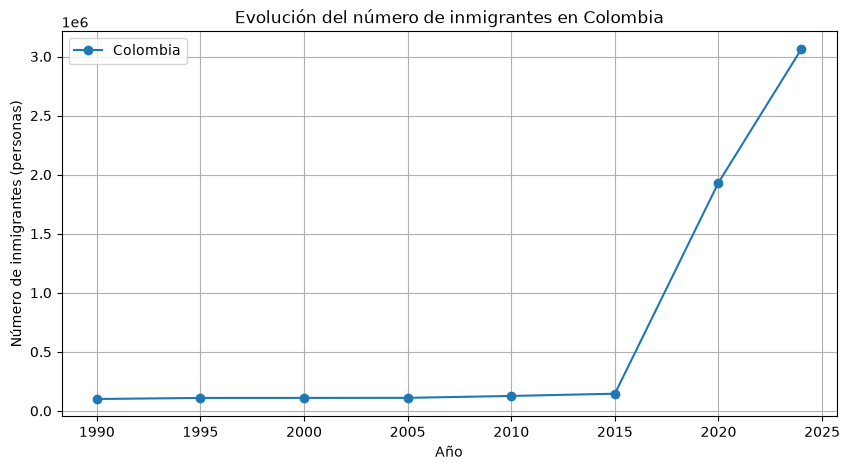

In [60]:
plt.figure(figsize=(10, 5))

plt.plot(
    anios_colombia,
    valor_colombia,
    label="Colombia",
    marker="o"
)

plt.title("Evolución del número de inmigrantes en Colombia")
plt.xlabel("Año")
plt.ylabel("Número de inmigrantes (personas)")
plt.grid(True)
plt.legend()


**Interpretación:**

Se puedo observar como en Colombia tu un crecimiento drastico en los ultimos 11 años, esto se debe a las crisis en Venezuela, que lleva a millones de venezolanos a migrar a Colombia. La tendencia es creciente pero no constante

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [61]:
# Pregunta 6
mexico = df_paises[df_paises["entity"] == "Mexico"]
mexico[["entity", "year", "valor"]]



,entity,year,valor
1192,Mexico,1990,701513
1193,Mexico,1995,458051
1194,Mexico,2000,526172
1195,Mexico,2005,701803
1196,Mexico,2010,957593
1197,Mexico,2015,1088731
1198,Mexico,2020,1335154
1199,Mexico,2024,1726089


In [62]:
anios_mexico = mexico["year"].to_numpy()
valor_mexico = mexico["valor"].to_numpy()

primer_anio = anios_mexico[0]
ultimo_anio = anios_mexico[-1]

valor_inicial = valor_mexico[0]
valor_final = valor_mexico[-1]

cambio_porcentual = ((valor_final - valor_inicial) / valor_inicial) * 100

print("Primer año:", primer_anio, "-", valor_inicial)
print("Último año:", ultimo_anio, "-", valor_final)
print("Cambio porcentual:", round(cambio_porcentual, 2), "%")


Primer año: 1990 - 701513
Último año: 2024 - 1726089
Cambio porcentual: 146.05 %


**Interpretación:**

México tuvo un incremento relativo de aprox 146 %: pasó de aprox 701,000 inmigrantes en 1990 a unos 1.73 millones en 2024. La cantidad bajó en 1995 y desde ahí creció sin parar. Creo que se debe a que México pasó de ser solo un país de origen y de tránsito hacia Estados Unidos a ser también un país de destino. Llegan personas de Centroamérica, Venezuela y Haití, y muchos migrantes se quedan en México por las políticas migratorias de Estados Unidos. También influyen los estadounidenses que viven en México, que son uno de los grupos de inmigrantes más grandes.

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [63]:
# Pregunta 7
anio = df_paises["year"].max()

valores = df_paises.loc[df_paises["year"] == anio, "valor"].to_numpy()

# Filtrar los NaN
valores = valores[~np.isnan(valores)]

print("Año:", anio)
print("Número de países:", len(valores))


Año: 2024
Número de países: 228


In [64]:
media = np.mean(valores)
mediana = np.median(valores)
desviacion_estandar = np.std(valores)

print("Media:", media)
print("Mediana:", mediana)
print("Desviación estándar:", desviacion_estandar)


Media: 1332886.144736842
Mediana: 202554.0
Desviación estándar: 4083060.7011782746


**Interpretación:**

La media de 1.33 millones es más de 6 veces mayor que la mediana de 203,000. Esto indica que los en la balanza de los datos se decanta mas a la derecha: la mayoría de los países tienen pocos inmigrantes, y unos cuantos, como Estados Unidos , suben mucho el promedio. La desviación estándares tres veces la media, así que los valores varían muchísimo entre países. Aquí la mediana representa mejor a un país típico que la media.

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

In [65]:
# Pregunta 8
mexico = df_paises[df_paises["entity"] == "Mexico"]
colombia = df_paises[df_paises["entity"] == "Colombia"]
espana = df_paises[df_paises["entity"] == "Spain"]

anios_mexico = mexico["year"].to_numpy()
valor_mexico = mexico["valor"].to_numpy()

anios_colombia = colombia["year"].to_numpy()
valor_colombia = colombia["valor"].to_numpy()

anios_espana = espana["year"].to_numpy()
valor_espana = espana["valor"].to_numpy()


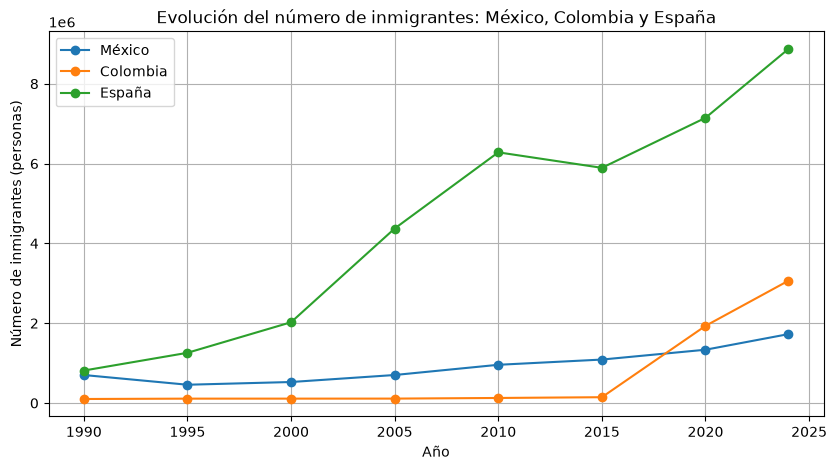

In [66]:
plt.figure(figsize=(10, 5))

plt.plot(
    anios_mexico,
    valor_mexico,
    label="México",
    marker="o"
)

plt.plot(
    anios_colombia,
    valor_colombia,
    label="Colombia",
    marker="o"
)

plt.plot(
    anios_espana,
    valor_espana,
    label="España",
    marker="o"
)

plt.title("Evolución del número de inmigrantes: México, Colombia y España")
plt.xlabel("Año")
plt.ylabel("Número de inmigrantes (personas)")
plt.grid(True)
plt.legend()
plt.show()



**Interpretación:**

Los tres países tienen más inmigrantes en 2024 que en 1990, pero cada uno creció de forma distinta. España crece mucho entre 2000 y 2010 y tiene una ligera caída en 2015, probablemente por factores economicos que haya sufrido españa. Luego vuelve a subir hasta 8.9 millones. México crece de forma lenta y constante. Colombia está casi plana hasta 2015 y luego sube de golpe por la migración venezolana, hasta superar a México en 2020.

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

In [73]:
# Pregunta 9
anios_disponibles = df_paises["year"].unique()
print("Años disponibles:", anios_disponibles)

anio_nacimiento = 2006
anio_reciente = 2023

# Año disponible mas cercano a cada uno
anio_1 = anios_disponibles[np.argmin(np.abs(anios_disponibles - anio_nacimiento))]
anio_2 = anios_disponibles[np.argmin(np.abs(anios_disponibles - anio_reciente))]

print("Año usado en lugar de", anio_nacimiento, ":", anio_1)
print("Año usado en lugar de", anio_reciente, ":", anio_2)


Años disponibles: [1990 1995 2000 2005 2010 2015 2020 2024]
Año usado en lugar de 2006 : 2005
Año usado en lugar de 2023 : 2024


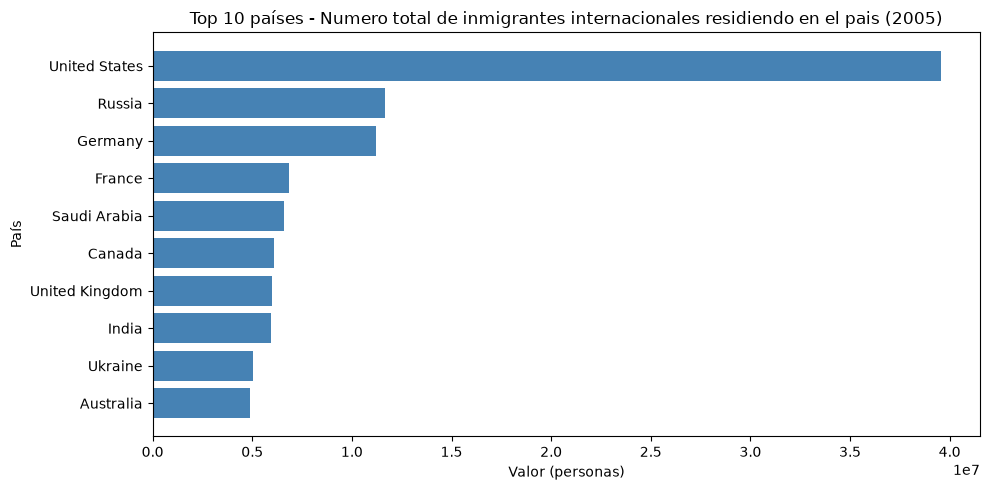

In [74]:
top_1 = (
    df_paises[df_paises["year"] == anio_1]
    .sort_values("valor", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top_1["entity"], top_1["valor"], color="steelblue")

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top 10 países - {config['descripcion']} ({anio_1})")

plt.gca().invert_yaxis()  # para que el pais con el valor mas alto quede arriba
plt.tight_layout()
plt.show()


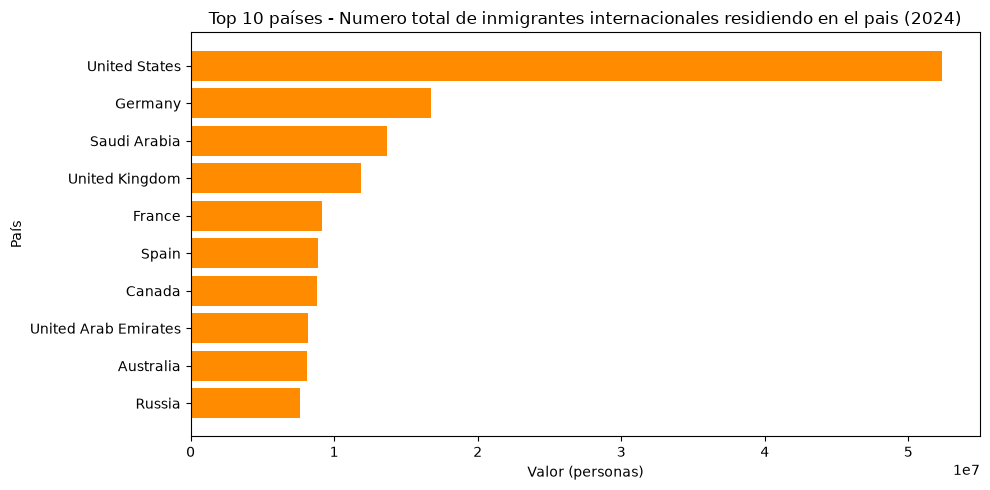

In [76]:
top_2 = (
    df_paises[df_paises["year"] == anio_2]
    .sort_values("valor", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top_2["entity"], top_2["valor"], color="darkorange")

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top 10 países - {config['descripcion']} ({anio_2})")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Interpretación:**

Como el dataset solo tiene datos cada 5 años, usé 2005 (el más cercano a mi nacimiento, 2006) y 2024 (el más cercano a 2023). Estados Unidos sigue en primer lugar en ambos años y pasó de 39.5 a 52.4 millones. Rusia bajó del Segundo al decimo lugar, y India y Ucrania salieron del Top 10. Sus cifras venían de personas nacidas en otras repúblicas, y esas generaciones han ido disminuyendo. Subieron Arabia Saudita (Quinto al Tercero) y Reino Unido (Septimo al Cuarto), y entraron España y Emiratos Árabes Unidos. Es decir, ahora dominan los países que atraen trabajadores por su economía. En general, todos los valores crecieron.

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

El dataset de migración de Our World in Data muestra el número de inmigrantes que viven en cada país, de 1990 a 2024. Encontré que la migración ha crecido en casi todo el mundo y que está muy concentrada en pocos países: Estados Unidos tiene por mucho la mayor cantidad. Le siguen países con economías fuertes como Alemania, Arabia Saudita y Reino Unido. También vi que los eventos históricos cambian mucho los datos: la crisis en Venezuela hizo que Colombia pasara de 145,000 a más de 3 millones de inmigrantes. México también creció 146 % y hoy es cada vez más un país de destino.

La información tiene limitaciones. Los valores son absolutos y no consideran la población, así que favorecen a los países grandes. Los datos son cada 5 años, por eso no pude usar 2006 ni 2023 y tuve que tomar los años más cercanos. Además, la distribución está muy sesgada (la media es 6 veces la mediana), y eso hace que el promedio no represente bien a un país típico. Si tuviera más tiempo, calcularía el porcentaje de inmigrantes respecto a la población de cada país y lo compararía con datos de emigración para ver qué países pierden y cuáles ganan población por migración.

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
